# Análisis de desempeño RappiPlus

Análisis de desempeño económico del servicio RappiPlus durante la primera mitad de 2025 (01/01/2025 -  30/06/2025).

Datasets utilizados:
- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue.  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores.  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país.

Flujo metodológico:

Carga y validación de datos →  Análisis de rentabilidad → Comunicación de resultados (Dashboard)

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

##Carga y validación  de la calidad de los datos

###Carga de datos y vista rápida

Carga de archivos:
- `rappiplus_orders_raw.csv`: orders
- `rappiplus_catalog.csv`: catalog
- `rappiplus_marketing_spend.csv`: marketing

In [ ]:
#Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Carga de archivos
orders = pd.read_csv('rappiplus_orders_raw.csv')
catalog = pd.read_csv('rappiplus_catalog.csv')
marketing = pd.read_csv('rappiplus_marketing_spend.csv')

In [ ]:
#Exploración inicial
orders.head(5)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


| Columna          | Tipo de dato | Descripción                              |
|------------------|--------------|------------------------------------------|
| id_pedido        | Categórica   | ID único del pedido                      |
| id_usuario       | Categórica   | Identificador del usuario que realizó el pedido |
| fecha_hora_pedido| Fecha        | Fecha en la que se realizó el pedido    |
| pais             | Categórica   | País desde donde se realizó el pedido   |
| dispositivo      | Categórica   | Dispositivo utilizado para realizar el pedido |
| fuente_referencia| Categórica   | Canal de adquisición del usuario        |
| nombre_producto  | Categórica   | Nombre del producto comprado             |
| categoria_producto | Categórica | Categoría del producto                  |
| cantidad         | Numérico     | Cantidad de productos comprados         |
| precio_unitario  | Numérico     | Precio por unidad del producto          |
| monto_descuento  | Numérico     | Descuento aplicado al pedido             |
| monto_total      | Numérico     | Monto total pagado por el pedido        |

In [ ]:
catalog.head(5)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


| Columna | Tipo de dato | Descripción |
|---|---|---|
| nombre_producto | Categórica | Nombre del producto |
| categoria_producto | Categórica | Categoría a la que pertenece el producto |
| costo_unitario | Numérico | Costo por unidad del producto |
| proveedor | Categórica | Empresa proveedora del producto |


In [ ]:
marketing.head(5)

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


| Columna | Tipo de dato | Descripción |
|---|---|---|
| fecha | Fecha | Fecha en la que se realizó la inversión |
| pais | Categórica | País donde se ejecutó la campaña |
| id_campaña | Categórica | Identificador único de la campaña |
| canal | Categórica | Canal de marketing utilizado |
| gasto | Numérico | Monto invertido en la campaña |

---

### Revisión y calidad de datos

**Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas


**Orders**

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [ ]:
orders['fecha_hora_pedido']=pd.to_datetime(orders['fecha_hora_pedido'],errors='coerce')
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                24800 non-null  object        
 4   dispositivo         25080 non-null  object        
 5   fuente_referencia   25070 non-null  object        
 6   nombre_producto     25070 non-null  object        
 7   categoria_producto  25020 non-null  object        
 8   cantidad            25050 non-null  float64       
 9   precio_unitario     25050 non-null  float64       
 10  monto_descuento     25050 non-null  float64       
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.3+ MB


In [ ]:
orders[orders['cantidad']<=0]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,NaN,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,NaN,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53


In [ ]:
orders = orders[orders['cantidad']>0]

orders[orders['cantidad']<=0]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [ ]:
orders_rev = orders.copy()

In [ ]:
orders_rev['monto_total_calc'] = (orders_rev['cantidad'] * orders_rev['precio_unitario']) - orders_rev['monto_descuento']
orders_rev['dif'] = orders_rev['monto_total']-orders_rev['monto_total_calc']
orders_rev[['monto_total','monto_total_calc','dif']].sort_values('dif')

,monto_total,monto_total_calc,dif
21047,823.31,823.32,-0.01
20842,709.31,709.32,-0.01
11923,540.93,540.94,-0.01
20885,645.31,645.32,-0.01
20696,796.93,796.94,-0.01
...,...,...,...
21412,895.69,895.68,0.01
8129,970.07,970.06,0.01
7750,764.69,764.68,0.01
7721,872.07,872.06,0.01


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25046 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25046 non-null  object        
 1   id_usuario          25046 non-null  object        
 2   fecha_hora_pedido   25046 non-null  datetime64[ns]
 3   pais                24750 non-null  object        
 4   dispositivo         25026 non-null  object        
 5   fuente_referencia   25016 non-null  object        
 6   nombre_producto     25016 non-null  object        
 7   categoria_producto  25016 non-null  object        
 8   cantidad            25046 non-null  float64       
 9   precio_unitario     25046 non-null  float64       
 10  monto_descuento     25046 non-null  float64       
 11  monto_total         25046 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.5+ MB


In [ ]:
orders['id_pedido'].value_counts()

,count
id_pedido,
order_5615,2
order_13811,2
order_974,2
order_16555,2
order_14695,2
...,...
order_8382,1
order_8381,1
order_8380,1


In [ ]:
orders = orders.drop_duplicates(subset='id_pedido',keep='first')

orders['id_pedido'].value_counts()

,count
id_pedido,
order_24999,1
order_0,1
order_24983,1
order_24982,1
order_24981,1
...,...
order_6,1
order_5,1
order_4,1


In [ ]:
#IQR
Q1 = orders['monto_total'].quantile(0.25)
Q3 = orders['monto_total'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

orders[(orders['monto_total']<lower) | (orders['monto_total']>upper)].sort_values('monto_total')

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,43.14,0.0,431400.0
3689,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,87.69,0.0,876900.0
3643,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,238.15,0.0,2381500.0
3522,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,280.55,0.0,2805500.0
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000.0,336.93,0.0,3369300.0
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,490.35,0.0,4903500.0
3726,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000.0,290.85,0.0,5817000.0
3656,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electronica,20000.0,297.66,0.0,5953200.0
3668,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,348.31,0.0,6966200.0
3722,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,442.01,0.0,8840200.0


In [ ]:
orders = orders.fillna({'nombre_producto':'Desconocido','categoria_producto':'Otros'})
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24946 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24946 non-null  object        
 1   id_usuario          24946 non-null  object        
 2   fecha_hora_pedido   24946 non-null  datetime64[ns]
 3   pais                24650 non-null  object        
 4   dispositivo         24926 non-null  object        
 5   fuente_referencia   24916 non-null  object        
 6   nombre_producto     24946 non-null  object        
 7   categoria_producto  24946 non-null  object        
 8   cantidad            24946 non-null  float64       
 9   precio_unitario     24946 non-null  float64       
 10  monto_descuento     24946 non-null  float64       
 11  monto_total         24946 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.5+ MB


**Catalog**

In [ ]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 356.0+ bytes


**Marketing**

In [ ]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [ ]:
marketing['fecha'] = pd.to_datetime(marketing['fecha'],errors='coerce')
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


**Notas de limpieza:**

- El formato de los tipos de datos se encuentra correcto en todas las columnas, excepto la columna `fecha_hora_pedido` en orders y la columna `fecha` en marketing. Se realizó una conversión a tipo datetime por medio de la función pd.to_datetime.

- En el caso de las variables numéricas de los tres datasets, los valores numéricos se encuentran en el formato correcto. Se detectó la presencia de cuatro valores inválidos en la columna `cantidad` de la tabla orders, para lo cual se decidió eliminar dichos valores para no afectar las métricas posteriores.

- Los valores calculados como la columna `monto_total` en la tabla orders muestran valores consitentes con el cálculo manual de las variables, por lo que no fue necesario realizar cambios.

- Se eliminaron filas duplicadas en la tabla orders utilizando como variable de referencia a la columna `id_pedido`.

- Se encontraron 10 valores atípicos en la columna `monto_total` de la tabla orders, los cuales han sido conservados por contener información importante sobre los ingresos de la empresa durante el periódo analizado.

- Debido a la importancia de las variables categóricas para métricas segmentadas, se ha decidido tratar los datos nulos en las columnas `categoria_producto` y `nombre_producto` llenando los valores faltantes con la etiqueta "Otros" y "Desconocido" respectivamente. Se han conservado los datos de transacciones correspondientes debido a su importancia en el cálculo de los ingresos y métricas de retornos.


**Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

##Análisis de rentabilidad


###Cálculo de KPIs principales

**Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`).

**KPI's a calcular:**
- Ingreso total.
- Costo total.
- Inversión en marketing.
- Utilidad.  
- Ticket promedio de orden.
- Cantidad promedio por orden.
- Producto más vendido.
- Gasto en marketing por canal.

In [ ]:
#Datasets
orders_clean = pd.read_csv('orders_clean.csv')
catalog_clean = pd.read_csv('catalog_clean.csv')
marketing_clean = pd.read_csv('marketing_clean.csv')

In [ ]:
#Unión de tablas necesarias
orders_short = orders_clean[['id_pedido','nombre_producto','cantidad','precio_unitario','monto_descuento','monto_total']]
catalog_short = catalog_clean[['nombre_producto','costo_unitario']]

revenue_report = pd.merge(orders_short,catalog_short,on=['nombre_producto'],how='left')
revenue_report

,id_pedido,nombre_producto,cantidad,precio_unitario,monto_descuento,monto_total,costo_unitario
0,order_0,Jacket-Winter-M,2.0,332.69,0.0,665.37,189.31
1,order_1,Tablet-Standard-64GB,1.0,176.86,5.0,171.86,25.21
2,order_2,Blender-XL-Red,2.0,102.99,10.0,195.99,176.64
3,order_3,Tablet-Standard-64GB,1.0,257.87,15.0,242.87,25.21
4,order_4,Blender-XL-Red,1.0,336.28,0.0,336.28,176.64
...,...,...,...,...,...,...,...
24941,order_24995,Tablet-Standard-64GB,1.0,64.57,0.0,64.57,25.21
24942,order_24996,Vacuum-Pro-Black,2.0,292.90,15.0,570.81,16.60
24943,order_24997,Jacket-Winter-M,1.0,226.85,0.0,226.85,189.31
24944,order_24998,Sneakers-Urban-42,2.0,418.06,0.0,836.12,17.21


In [ ]:
#Ingreso total
total_revenue = round(revenue_report['monto_total'].sum(),2)
print(f'Ingreso total: ${total_revenue}')

Ingreso total: $51966981.56


In [ ]:
#Costo total
total_cost = revenue_report['costo_unitario'] * revenue_report['cantidad']
total_cost = round(total_cost.sum(),2)

print(f'Costo total de prouctos: ${total_cost:2f}')

Costo total de prouctos: $43124069.010000


In [ ]:
#Inversión en marketing
gasto_total_mktg = round(marketing_clean['gasto'].sum(),2)

print(f'Inversión en marketing: ${gasto_total_mktg}')

Inversión en marketing: $2871843.53


In [ ]:
#Utilidad
profit = round(total_revenue - total_cost - gasto_total_mktg,2)
margen = round((profit / total_revenue) * 100,2)

print(f'Utilidad: ${profit:2f}')
print(f'Margen: {margen:2f}%')

Utilidad: $5971069.020000
Margen: 11.490000%


In [ ]:
#Ticket promedio de orden
ticket_promedio = round(revenue_report['monto_total'].mean(),2)

print(f'Ticket promedio por orden: ${ticket_promedio:2f}')

Ticket promedio por orden: $2083.180000


In [ ]:
#Cantidad promedio por orden
cantidad_promedio = round(revenue_report['cantidad'].mean(),2)

print(f'Cantidad promedio por orden: {cantidad_promedio}')

Cantidad promedio por orden: 7.12


In [ ]:
#Tabla resumen
summary = pd.Series({
    'Ingreso total': f'${total_revenue}',
    'Costo total': f'${total_cost}',
    'Inversión en marketing': f'${gasto_total_mktg}',
    'Utilidad': f'${profit}',
    'Margen': f'{margen}%',
    'Ticket promedio de orden': f'${ticket_promedio}',
    'Cantidad promedio por orden': f'{cantidad_promedio}'
})

summary.name = 'Monto'

summary

,Monto
Ingreso total,$51966981.56
Costo total,$43124069.01
Inversión en marketing,$2871843.53
Utilidad,$5971069.02
Margen,11.49%
Ticket promedio de orden,$2083.18
Cantidad promedio por orden,7.12


In [ ]:
#Producto más vendido
revenue_report.groupby('nombre_producto')['cantidad'].sum().sort_values()

,cantidad
nombre_producto,
Desconocido,45.0
Phone-Pro-128GB,4140.0
Tablet-Standard-64GB,4153.0
Sneakers-Urban-42,6172.0
Jacket-Winter-M,6256.0
Blender-XL-Red,6279.0
Vacuum-Pro-Black,6284.0
Laptop-Gaming-16GB,144198.0


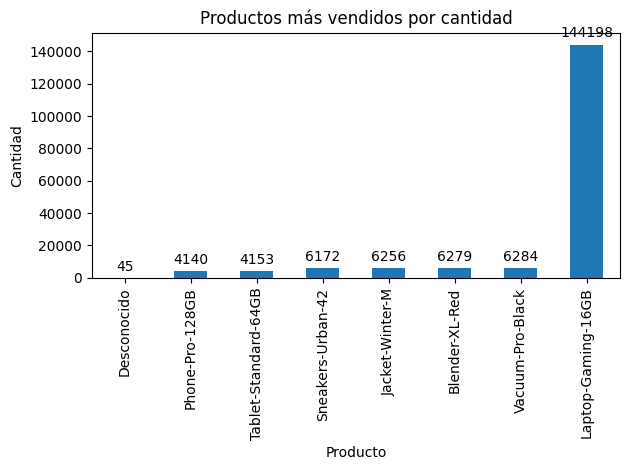

In [ ]:
productos_mas_vendidos = revenue_report.groupby('nombre_producto')['cantidad'].sum().sort_values()

ax = productos_mas_vendidos.plot(kind='bar')
plt.title('Productos más vendidos por cantidad')
plt.xlabel('Producto')
plt.ylabel('Cantidad')

ax.bar_label(ax.containers[0], fmt='%d', label_type='edge', padding=3)
plt.tight_layout()
plt.show()

In [ ]:
#Gasto en marketing por canal
marketing.groupby('canal')['gasto'].sum().sort_values()

,gasto
canal,
paid_search,863088.21
organic,913533.01
social,918043.21


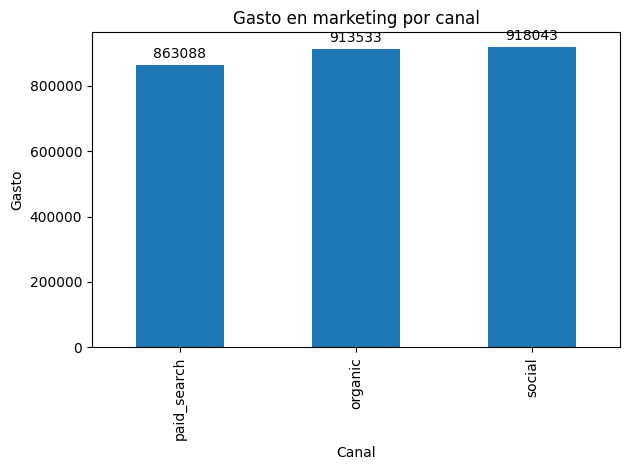

In [ ]:
gasto_mktg_canal = marketing.groupby('canal')['gasto'].sum().sort_values()

ax = gasto_mktg_canal.plot(kind='bar')
plt.title('Gasto en marketing por canal')
plt.xlabel('Canal')
plt.ylabel('Gasto')

ax.bar_label(ax.containers[0], fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

###**Hallazgos**



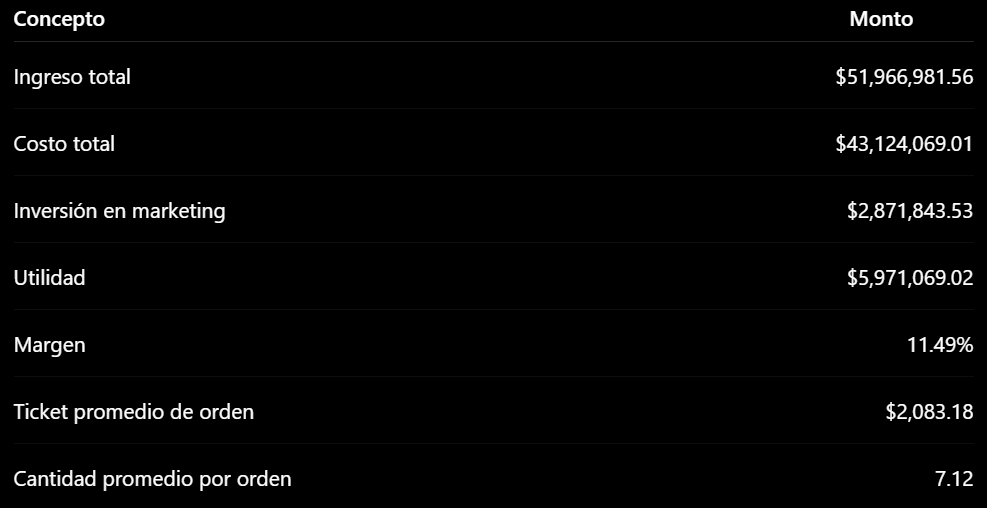

- El ingreso YTD al 30 de junio de 2025 fue de 51.96 millones de dólares.
- Durante el periódo el costo total de los productos vendidos fue de 43.12 millones de dólares, equivalente a un 83% del ingreso total.
- El costo de campañas de marketing fue de 2.87 millones, equivaliendo a un 5.5% del ingreso.
- Al descontar los costos, la utilidad del periódo fue de 5.97 millones, lo que representa un margen de utilidad de 11.49%.


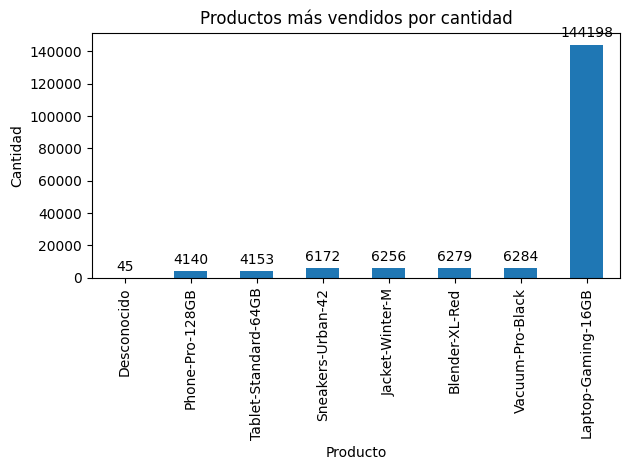

- El producto más vendido por bastante diferencia fue la Laptop-Gaming-16-GB, con 144,198 unidades vendidas en los primeros seis meses de 2025, por lo cual mantener este producto en inventario es clave para poder abastacer la demanda y mantener el nivel de ingreso obtenido hasta el momento.


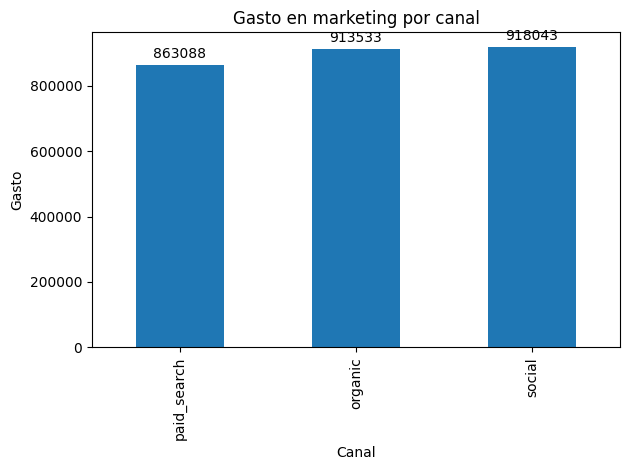

- La distribución de gasto en publicidad por canal es bastante equitativa, con el canal de redes sociales siendo ligeramente mayor debido a la importancia de esta vía de adquisición de clientes en la actualidad.

---

##Comunicación de resultados (dashboard)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios utilizados en el análisis de rentabilidad:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

**Preparación de los datos**
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).


**Dashboard 1: Overview Ejecutivo**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden


**Dashboard 2: Detalle por producto**
- Tabla de utilidad por producto con detalle de producto, cantidad, ingreso total, costo total, utilidad bruta.
- Gráfico de barras por producto con medida `cantidad vendida`

**Dashboard 3: Drill-through**
- Tabla de pedidos filtrada por el producto seleccionado en la tabla de "Utilidad por producto".

**Acceder al dashboard:** https://drive.google.com/file/d/1no4Op-XiwL-zbQtSixJPenZInxt9z8WL/view?usp=sharing